In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import sys; sys.path.append("../utils")
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

with open('../csc_lf_fileinfo.json', 'r') as f:
    lf_files = json.load(f)

### Quick overview figure

### Now put plots together into one large figure 

<>:153: SyntaxWarning: invalid escape sequence '\m'
<>:252: SyntaxWarning: invalid escape sequence '\e'
<>:153: SyntaxWarning: invalid escape sequence '\m'
<>:252: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_795863/3540404338.py:153: SyntaxWarning: invalid escape sequence '\m'
  axes_fft_plots[5,0].set_ylabel('$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)', y=4, labelpad=10.0)
/tmp/ipykernel_795863/3540404338.py:252: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$D/\epsilon_0$ (V/nm)')


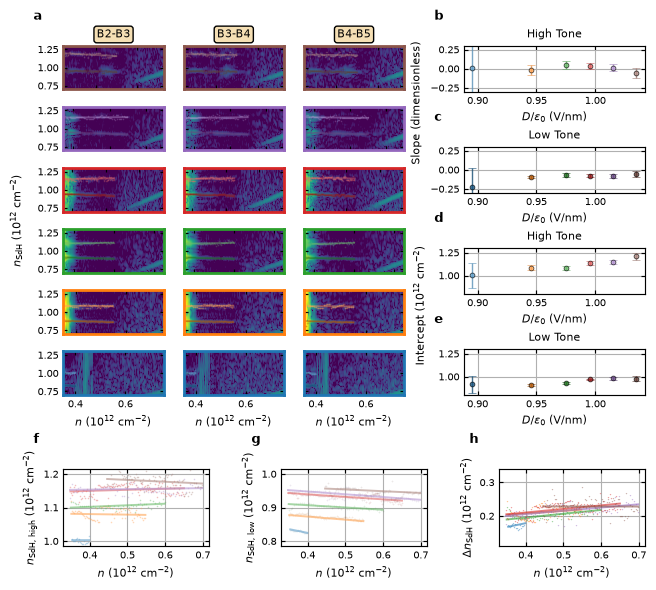

In [2]:
def get_peak_freq(freq, fft, target_peak_val):
    # Given a cut in freq and peak, find peaks most closely matching target_peak_vals
    peaks, _ = find_peaks(np.abs(fft)**2)
    if len(peaks) < 1:
        return np.nan
    peak_v = peaks[np.argmin(np.abs(freq[peaks] - target_peak_val))]
    return freq[peak_v]


def adjust_lightness(color, amount):
    # Modify color lightness by blending with white (for lightening) or black (for darkening)
    rgb = np.array(colors.to_rgb(color))
    if amount > 0:
        # Lighten: blend with white
        white = np.array([1, 1, 1])
        return colors.to_hex(tuple(rgb + amount * (white - rgb)))
    else:
        # Darken: blend with black
        black = np.array([0, 0, 0])
        return colors.to_hex(tuple(rgb + amount * (rgb - black)))


n_files = len(lf_files.keys())

# Two column
fig = plt.figure(figsize=(7.5, 6.5))
gs = GridSpec(17, 15, wspace=1.0, hspace=0.8, figure=fig)
gs_fft_plots = GridSpecFromSubplotSpec(n_files, 3, subplot_spec=gs[:12, :9], wspace=0.2, hspace=0.4)
gs_fits = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[14:,:], wspace=0.5, hspace=0.3)
gs_fit_params = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[:12, 10:], wspace=0.3, hspace=1.2)
axes_fft_plots = np.array([[
    plt.subplot(gs_fft_plots[i, j]) for j in range(3)
] for i in range(n_files)])
axes_fits = [
    plt.subplot(gs_fits[0, j]) for j in range(3)
]
axes_fit_params = [
    plt.subplot(gs_fit_params[i, 0]) for i in range(4)
]

scancolors = [x for x in colors.TABLEAU_COLORS.values()][:n_files]
letters = list(map(chr, range(97, 97+26)))

#### FFTs 
peak_params_dir = {
    '1888': (np.array([1.00, 0.82]), (0.34, 0.4)), # [Peak high, peak_lo], (nlo, nhi)
    '1886': (np.array([1.08, 0.87]), (0.34, 0.55)),
    '1958': (np.array([1.10, 0.90]), (0.34, 0.6)),
    '1840': (np.array([1.15, 0.93]), (0.34, 0.65)),
    '1957': (np.array([1.15, 0.95]), (0.34, 0.7)),
    '1885': (np.array([1.18, 0.95]), (0.34, 0.7)),
}

coefs = np.zeros((6, 3, 2))
coefs_stdev = np.zeros((6, 3, 2))
intercepts = np.zeros((6, 3, 2))
intercepts_stdev = np.zeros((6, 3, 2))
hi_all_files = []
lo_all_files = []
valid_all_files = []
density_all_files = []
ms = 0.1 # Marker size for peaks
label_spacer = 0.04
peak_ranges = []
for file_idx, (axes, (file, D)) in enumerate(zip(axes_fft_plots[::-1], lf_files.items())): 
    hi_all_contacts = []
    lo_all_contacts = []
    valid_all_contacts = []

    for i, ax in enumerate(axes):
        analyzer = Lf_analysis(file, contact=i+1)
        plot, (ffts, freqs) = analyzer.plot_fft_invcm(fig, ax, norm_psd,
            bg_method=lambda y, x: (x-np.mean(x),0),                    
            bg_method_params={},
            padding=8,
            blims=(0.62, 2.49),
            return_data=True
        )
        ax.set_ylim(0.7, 1.3)
        for spine in ax.spines.values():
            spine.set_edgecolor(scancolors[file_idx])
            spine.set_linewidth(2.0)

        # Peak fitting
        peak_eps = 0.1
        peak_targets, (nlo, nhi) = peak_params_dir[file]
        peaks_lo, peaks_hi = np.zeros_like(analyzer.density), np.zeros_like(analyzer.density)
        for j, (fft, freq) in enumerate(zip(ffts.T, freqs.T)):
            target_peak_vals = peak_targets/analyzer.density[j]
            peaks_hi[j] = get_peak_freq(freq, fft, target_peak_vals[0]) * analyzer.density[j]
            peaks_lo[j] = get_peak_freq(freq, fft, target_peak_vals[1]) * analyzer.density[j]

        hi_all_contacts.append(peaks_hi)
        lo_all_contacts.append(peaks_lo)
        valid_all = np.ones_like(analyzer.density, dtype=bool)
        for j, peaks in enumerate([peaks_hi, peaks_lo]):
            peak_color = adjust_lightness(scancolors[file_idx], amount=-0.3 if j else 0.3)
            valid = (np.abs(peaks - peak_targets[j]) < peak_eps) &  (analyzer.density > nlo) & (analyzer.density < nhi)
            valid_all = valid_all & valid
            ax.plot(
                analyzer.density[valid], peaks[valid], 's' if j else 'D', 
                alpha=0.7, markersize=ms, c=peak_color
            )
            model = linear_model.RANSACRegressor(
                residual_threshold=0.055,
            )
            
            fit = model.fit(analyzer.density[valid].reshape(-1,1), peaks[valid].reshape(-1,1))
            inlier_freqs = np.ravel(peaks[valid].reshape(-1,1)[model.inlier_mask_])
            inlier_densities  = np.ravel(analyzer.density[valid].reshape(-1,1)[model.inlier_mask_])
            
            linear_fitfunc = lambda x, c0, c1: c0+c1*x
            popt, pcov = scipy.optimize.curve_fit(
                linear_fitfunc,
                inlier_densities,
                inlier_freqs,
            )
            ax.plot(
                analyzer.density[valid], linear_fitfunc(analyzer.density[valid], *popt),  alpha=0.45, c=peak_color
            )
            intercepts[file_idx, i, j], coefs[file_idx, i, j] = popt
            intercepts_stdev[file_idx, i, j], coefs_stdev[file_idx, i, j] = np.sqrt(np.diag(pcov))

        valid_all_contacts.append(valid_all)
        if file_idx != 0:
            ax.set_xlabel('')
            ax.get_xaxis().set_ticklabels([])
            ax.set_ylabel('')

        if file_idx == len(lf_files)-1:
            ax.set_title(
                contact_names[i+1],
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="#f5dfb4",
                    edgecolor="k",
                    linewidth=1,
                    alpha=1,
                )  
            )

        else:
            ax.set_ylabel('')
        
        if i != 0:
            ax.get_yaxis().set_ticklabels([])

    density_all_files.append(analyzer.density)    
    hi_all_files.append(hi_all_contacts)
    lo_all_files.append(lo_all_contacts)
    valid_all_files.append(valid_all_contacts)

axes_fft_plots[5,0].set_ylabel('$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)', y=4, labelpad=10.0)

# Label
ax = axes_fft_plots[0][0]
pos = ax.get_position()
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, 'a', fontweight='bold')


### Plotting outputs and fits together
displacements = [d for d in lf_files.values()]
for i, (file_num, displacment) in enumerate(lf_files.items()):
    fit_func_lo = lambda x: np.median(coefs, axis=1)[i,1] * x + np.median(intercepts, axis=1)[i,1]
    fit_func_hi = lambda x: np.median(coefs, axis=1)[i,0] * x + np.median(intercepts, axis=1)[i,0]
    hi, lo, valid, nvals = np.array(hi_all_files[i]), np.array(lo_all_files[i]), np.array(valid_all_files[i]), np.array(density_all_files[i])
    valid = np.all(valid, axis=0)
    hi = np.median(hi, axis=0)[valid]
    lo = np.median(lo, axis=0)[valid]
    nvals = nvals[valid]
    ylim_extent = 0.115
   
    # Hi 
    ax = axes_fits[0]
    ax.plot(
        nvals, hi, 'D', markersize=ms, 
        c=adjust_lightness(scancolors[i], amount=0.3)
    )
    ax.plot(
        nvals, fit_func_hi(nvals), label=f'{displacment:.3f} V/nm',
        alpha=0.6, c=adjust_lightness(scancolors[i], amount=0.3)
    )
    ax.set_ylabel(r'$n_{\mathrm{SdH}, \, \mathrm{high}}$ ($10^{12}$ cm$^{-2}$)')
    ylim_center = 1.1
    ax.set_ylim(ylim_center-ylim_extent, ylim_center+ylim_extent)
    # Low
    ax = axes_fits[1]
    ax.plot(
        nvals, lo, 's', markersize=ms/3,
        c=adjust_lightness(scancolors[i], amount=-0.3)
    )
    ax.plot(
        nvals, fit_func_lo(nvals), label=f'{displacment:.3f} V/nm', alpha=0.6, 
        c=adjust_lightness(scancolors[i], amount=0.3)
    )
    ax.set_ylabel(r'$n_{\mathrm{SdH}, \, \mathrm{low}}$ ($10^{12}$ cm$^{-2}$)')
    ylim_center = 0.9
    ax.set_ylim(ylim_center-ylim_extent, ylim_center+ylim_extent)
    # Diff
    ax = axes_fits[2]
    ax.plot(nvals, hi-lo, '^', c=scancolors[i], markersize=ms)
    ax.plot(nvals, fit_func_hi(nvals)- fit_func_lo(nvals), label=f'{displacment:.3f} V/nm', alpha=0.6, c=scancolors[i])
    ax.set_ylabel(r'$\Delta n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
    ylim_center = 0.225
    ax.set_ylim(ylim_center-ylim_extent, ylim_center+ylim_extent)


for i, ax in enumerate(axes_fits):
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+5], fontweight='bold')
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.grid(True)


# ### fit params
for i, ax in enumerate(axes_fit_params):
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+1], fontweight='bold')
    if i // 2 == 0:
        
        for j, point in enumerate(displacements):
            point_c = [adjust_lightness(sc, amount=-0.3 if i%2 else 0.3) for sc in scancolors][j]
            ax.errorbar(
                point, np.median(coefs, axis=1)[j,i%2], 
                yerr = 2*np.median(coefs_stdev, axis=1)[j,i%2],
                marker='o', 
                elinewidth=1, capsize=3, color=adjust_lightness(point_c, amount=-0.1),
                markerfacecolor=point_c, markeredgecolor='k', markersize=3.5, alpha=0.8, markeredgewidth=0.5,
                # color=adjust_lightness('#696969', amount=-0.3 if i%2 else 0.3)
            )
        ax.set_ylim(-0.3, 0.3)
        if i%2 == 0:
            ax.set_ylabel('Slope (dimensionless)', y=-0.25, labelpad=6)
    else: 
        for j, point in enumerate(displacements):
            point_c = [adjust_lightness(sc, amount=-0.3 if i%2 else 0.3) for sc in scancolors][j]
            ax.errorbar(
                point, np.median(intercepts, axis=1)[j,i%2],
                yerr = 2*np.median(intercepts_stdev, axis=1)[j,i%2],
                marker='o', 
                elinewidth=1, capsize=3, color=adjust_lightness(point_c, amount=-0.1),
                markerfacecolor=point_c, markeredgecolor='k', markersize=3.5, alpha=0.8, markeredgewidth=0.5,
                # c=adjust_lightness('#696969', amount=-0.3 if i%2 else 0.3)    
            )
        ax.set_ylim(0.8, 1.3)
        if i%2 == 0:
            ax.set_ylabel(r'Intercept ($10^{12}$ cm$^{-2}$)', y=-0.25, labelpad=8)
    
    ax.set_title("Low Tone" if i % 2 else "High Tone")
    ax.grid(True)
    
    ax.set_xlabel('$D/\epsilon_0$ (V/nm)')
    

plt.savefig('ed-fig_QO_CSC_fits.pdf', dpi=1200, bbox_inches='tight',
            pad_inches=0.02, transparent=False)